<a href="https://colab.research.google.com/github/jupawest/SoSSProject/blob/main/voice_recognition_model4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
!pip install librosa numpy soundfile matplotlib scikit-learn

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import lfilter, find_peaks
from scipy.spatial.distance import euclidean
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import Javascript, display, Audio
from base64 import b64decode
import subprocess
from pathlib import Path
from google.colab import output, drive

# ==== Setup ====
drive.mount('/content/drive')
AUDIO_DIR = Path("/content/drive/MyDrive/voice_enrollments")
AUDIO_DIR.mkdir(exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
RECORD_JS = """
const sleep = t => new Promise(r=>setTimeout(r,t));
const readBlob = b=>new Promise(r=>{
  const fr = new FileReader();
  fr.onloadend = e => r(e.target.result);
  fr.readAsDataURL(b);
});
var record = t => new Promise(async r=>{
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const rec = new MediaRecorder(stream);
  const chunks = [];
  rec.ondataavailable = e => chunks.push(e.data);
  rec.start();
  await sleep(t);
  rec.stop();
  rec.onstop = async () => r(await readBlob(new Blob(chunks)));
});
"""


def record_audio(sec=3, wav_fn="input.wav"):
    display(Javascript(RECORD_JS))
    data = output.eval_js(f"record({sec*1000})")
    raw_fn = "temp.webm"
    with open(raw_fn, 'wb') as f:
        f.write(b64decode(data.split(',')[1]))
    subprocess.run(['ffmpeg', '-y', '-i', raw_fn, '-ar', '16000', '-ac', '1', wav_fn],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return wav_fn

In [73]:
def extract_features(path, n_mfcc=13, n_formants=3):
    data, sr = sf.read(path)
    if data.ndim > 1:
        data = np.mean(data, axis=1)  # convert to mono

    # --- MFCCs for timbre ---
    mfccs = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfccs.T, axis=0)

    # --- Delta MFCCs for phoneme transitions ---
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta_mean = np.mean(mfcc_delta.T, axis=0)

    # --- Formants via LPC ---
    def lpc_formants(signal, sr, order=12):
        a = librosa.lpc(signal, order=order)
        rts = np.roots(a)
        rts = [r for r in rts if np.imag(r) >= 0]
        angs = np.arctan2(np.imag(rts), np.real(rts))
        freqs = angs * (sr / (2*np.pi))
        freqs.sort()
        return freqs[:n_formants]

    formants = lpc_formants(data, sr, order=2 + sr // 1000)

    # --- Spectral features for richer timbre ---
    centroid = np.mean(librosa.feature.spectral_centroid(y=data, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=data, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=data, sr=sr))

    # --- Combine all features into one vector ---
    feature_vector = np.concatenate([
        mfcc_mean,            # timbre
        mfcc_delta_mean,      # phoneme patterns
        formants,             # vocal tract resonances
        [centroid, bandwidth, rolloff]  # additional timbre info
    ])

    return feature_vector

In [64]:
def normalize_similarity(sim):
    """Normalize similarity score to 0-100%"""
    return max(0, min(100, sim * 100))

def voice_similarity(path1, path2):
    """
    Compare two audio files and return similarity score (0-100)
    using MFCCs, delta MFCCs, formants, and spectral features.
    """
    # Extract features for both files
    feat1 = extract_features(path1)
    feat2 = extract_features(path2)

    # Compute Euclidean distance between feature vectors
    dist = euclidean(feat1, feat2)

    # Convert distance to similarity (smaller distance = higher similarity)
    # You can tweak the denominator to scale appropriately
    sim = 1 / (1 + dist)  # similarity in range (0,1)
    return normalize_similarity(sim)

In [53]:
def plot_waveform_mfcc_formants(path):
    y, sr = librosa.load(path, sr=16000)

    # --- Estimate formants via LPC ---
    def lpc_formants(signal, sr, order=12, n_formants=3):
        a = librosa.lpc(signal, order)
        rts = np.roots(a)
        rts = [r for r in rts if np.imag(r) >= 0]
        angs = np.arctan2(np.imag(rts), np.real(rts))
        freqs = angs * (sr / (2*np.pi))
        freqs.sort()
        return freqs[:n_formants]

    formants = lpc_formants(y, sr)

    # --- MFCCs and Delta MFCCs ---
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfccs)

    # --- Plot waveform with formants ---
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)
    for f in formants:
        plt.axhline(f/1000, color='r', linestyle='--', alpha=0.7, label=f'Formant ~{f:.1f} Hz')
    plt.title(f"Waveform & Formants of {Path(path).name}")
    plt.tight_layout()
    plt.show()

    # --- Plot MFCCs ---
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title('MFCCs (Timbre)')
    plt.tight_layout()
    plt.show()

    # --- Plot Delta MFCCs ---
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc_delta, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title('Delta MFCCs (Phoneme transitions)')
    plt.tight_layout()
    plt.show()

    display(Audio(path))

In [78]:
# Enrolling new audio for people
def enroll_user(user_name):
    wav_path = AUDIO_DIR / f"{user_name}.wav"
    print(f"🎙️ Recording for user: {user_name}")
    record_audio(sec=3, wav_fn=str(wav_path))
    print(f"✅ Enrolled {user_name} — Saved at {wav_path}")
    plot_waveform_mfcc_formants(str(wav_path))


In [40]:
def voice_authentication_mfcc(threshold=85, top_n=5):
    print("\n📥 Recording your test voice...")
    test_path = record_audio(sec=3, wav_fn="test.wav")
    print(f"✅ Recorded test sample: {test_path}")
    plot_waveform_mfcc_formants(test_path)
    test_vec = extract_features(test_path).reshape(1, -1)

    print("\n🔎 MFCC Similarity Comparison:")
    similarities = []

    for file in AUDIO_DIR.glob("*.wav"):
        user = file.stem
        enrolled_vec = extract_features(str(file)).reshape(1, -1)
        sim = cosine_similarity(test_vec, enrolled_vec)[0][0]
        sim_pct = normalize_similarity(sim)
        status = "✅ Pass" if sim_pct >= threshold else "❌ Fail"
        print(f"📂 {user}: {sim_pct:.1f}% similarity — {status}")
        similarities.append((user, sim_pct))

    sorted_sims = sorted(similarities, key=lambda x: x[1], reverse=True)
    print(f"\n🏆 Top {top_n} Matches:")
    for user, sim_pct in sorted_sims[:top_n]:
        print(f"  {user}: {sim_pct:.1f}%")

    best_user, best_sim = sorted_sims[0]
    if best_sim >= threshold:
        print(f"\n✅ Authentication successful: {best_user}")
    else:
        print("\n❌ Access Denied — No match found")


🎙️ Recording for user: user1


<IPython.core.display.Javascript object>

✅ Enrolled user1 — Saved at /content/drive/MyDrive/voice_enrollments/user1.wav


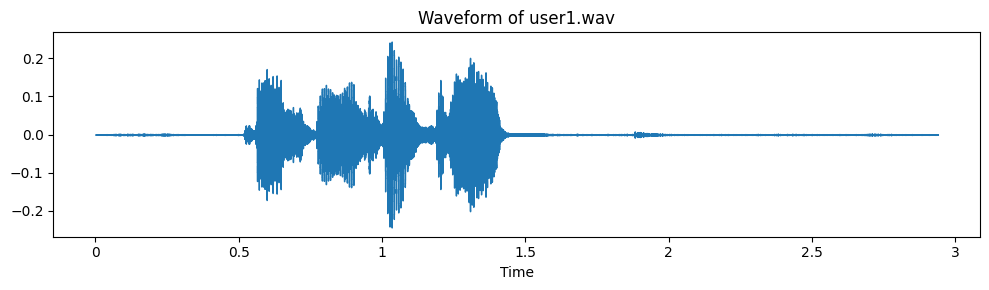

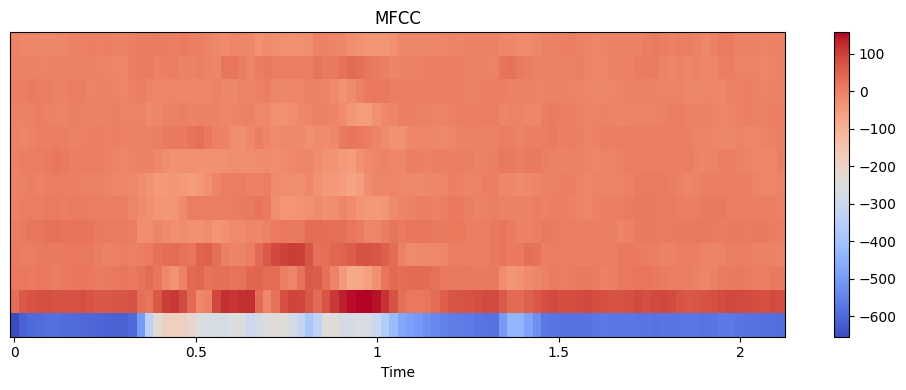

🎙️ Recording for user: user2


<IPython.core.display.Javascript object>

✅ Enrolled user2 — Saved at /content/drive/MyDrive/voice_enrollments/user2.wav


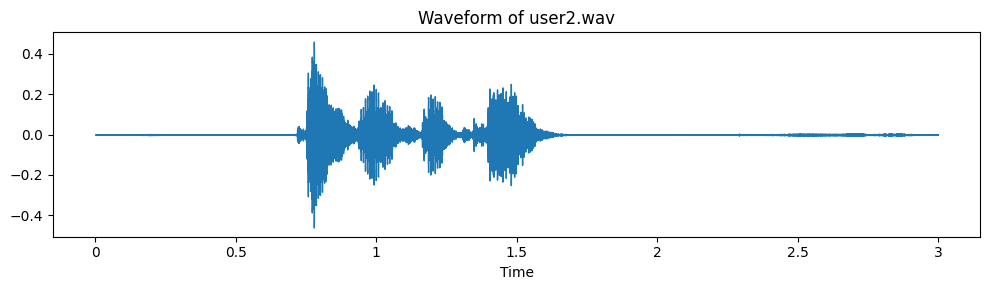

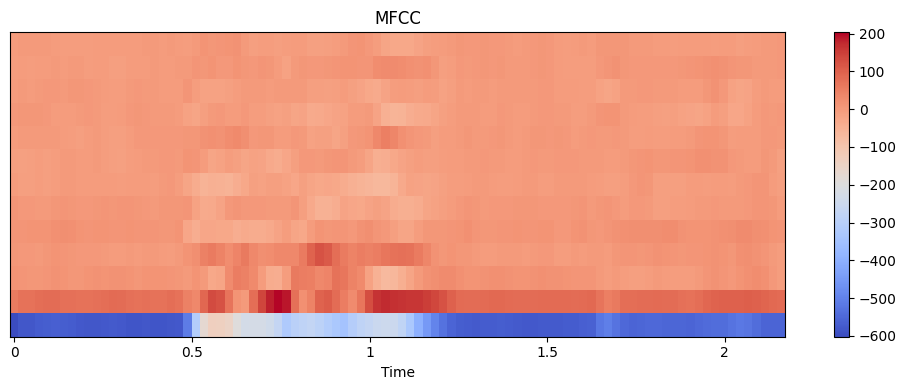

🎙️ Recording for user: user3


<IPython.core.display.Javascript object>

✅ Enrolled user3 — Saved at /content/drive/MyDrive/voice_enrollments/user3.wav


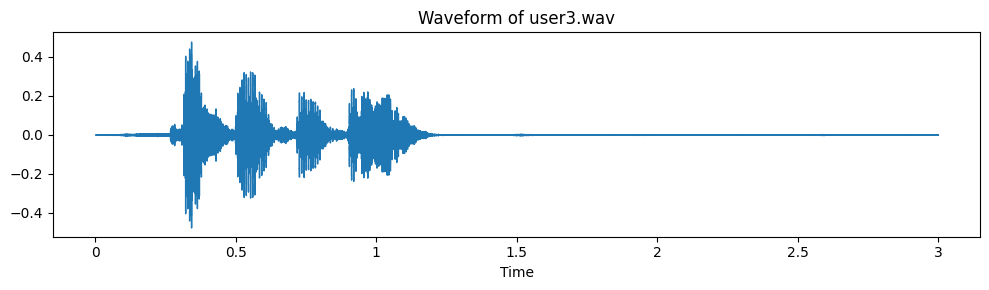

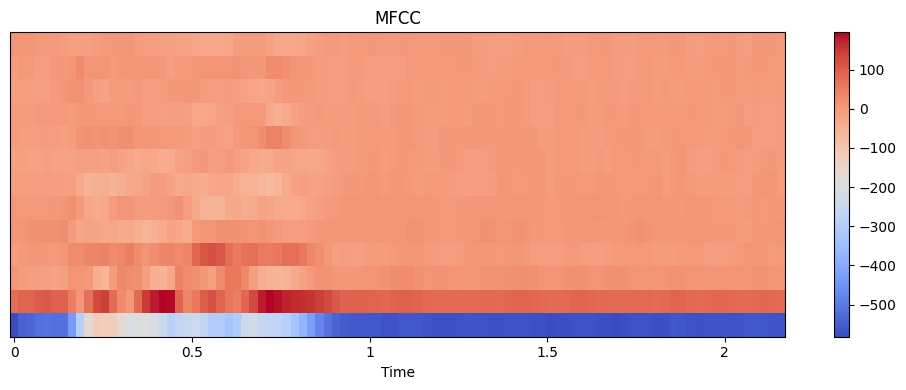

🎙️ Recording for user: user4


<IPython.core.display.Javascript object>

✅ Enrolled user4 — Saved at /content/drive/MyDrive/voice_enrollments/user4.wav


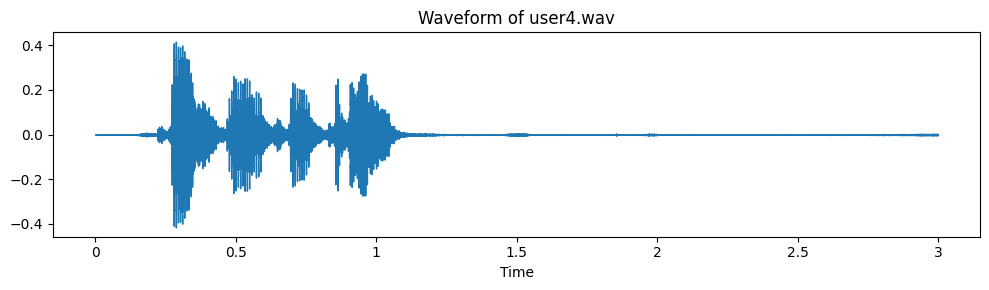

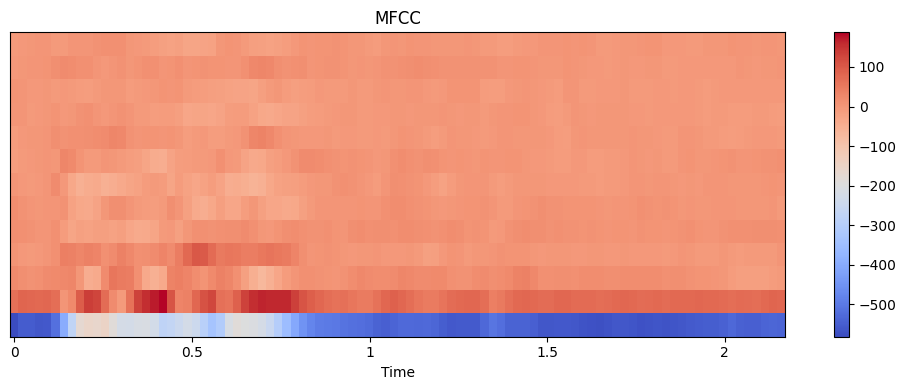

In [41]:
enroll_user("user1")
enroll_user("user2")
enroll_user("user3")
enroll_user("user4")

🎙️ Recording for user: user5


<IPython.core.display.Javascript object>

✅ Enrolled user5 — Saved at /content/drive/MyDrive/voice_enrollments/user5.wav


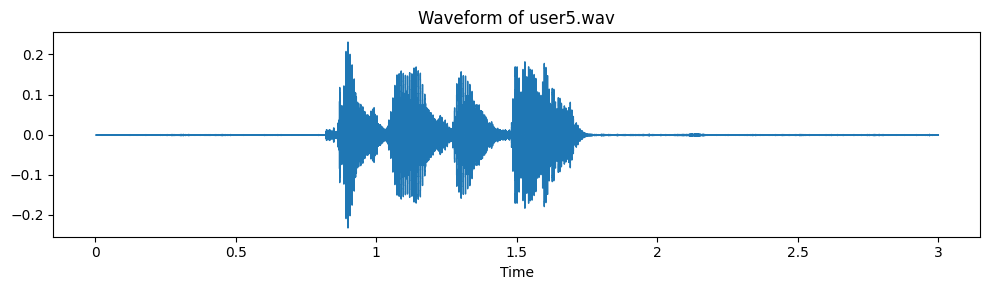

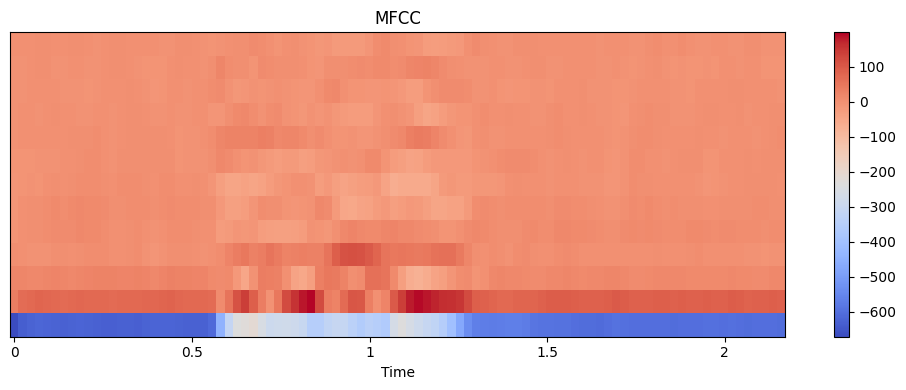

🎙️ Recording for user: user6


<IPython.core.display.Javascript object>

✅ Enrolled user6 — Saved at /content/drive/MyDrive/voice_enrollments/user6.wav


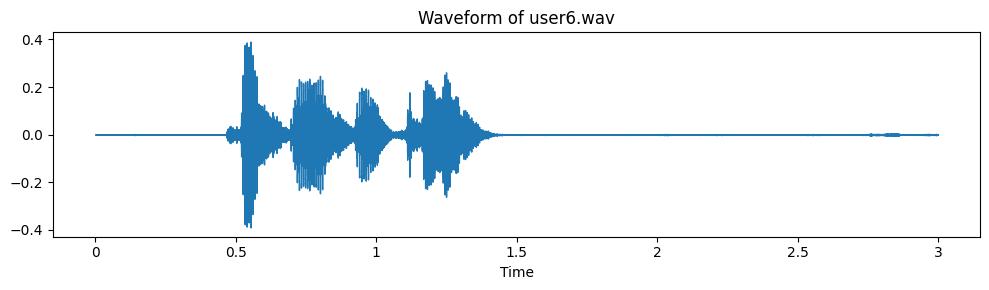

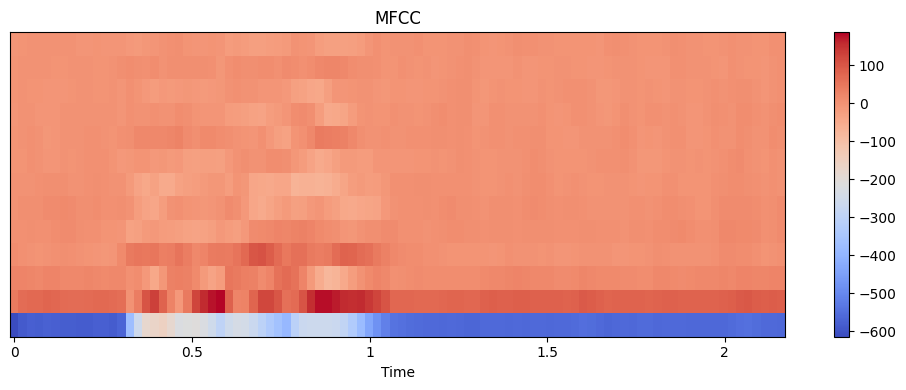

🎙️ Recording for user: user7


<IPython.core.display.Javascript object>

✅ Enrolled user7 — Saved at /content/drive/MyDrive/voice_enrollments/user7.wav


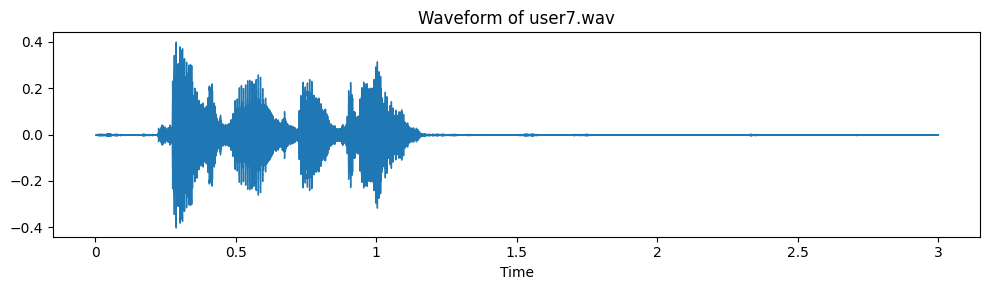

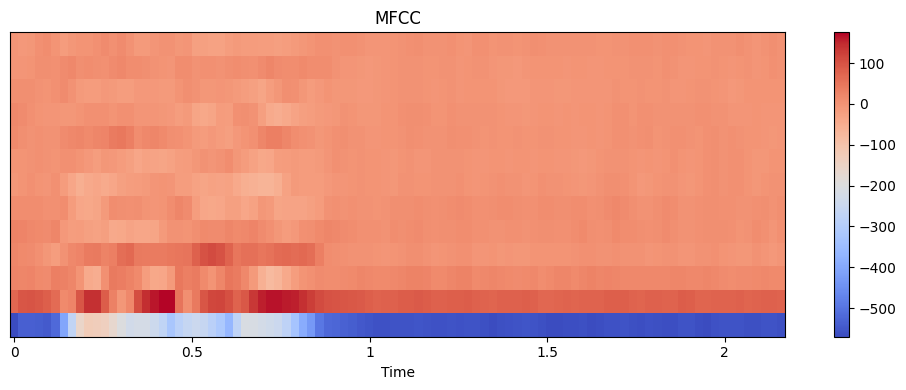

🎙️ Recording for user: user8


<IPython.core.display.Javascript object>

✅ Enrolled user8 — Saved at /content/drive/MyDrive/voice_enrollments/user8.wav


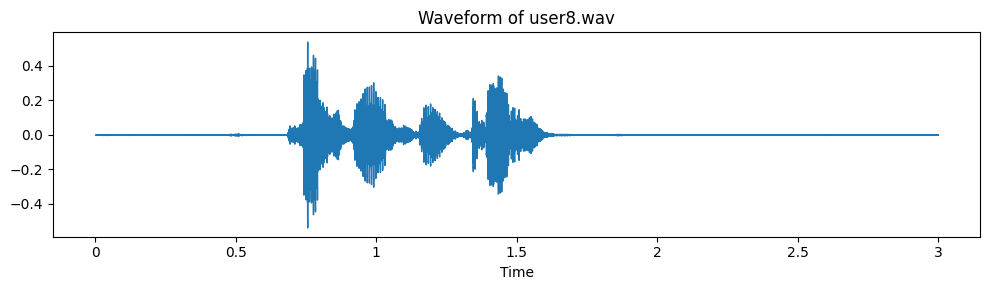

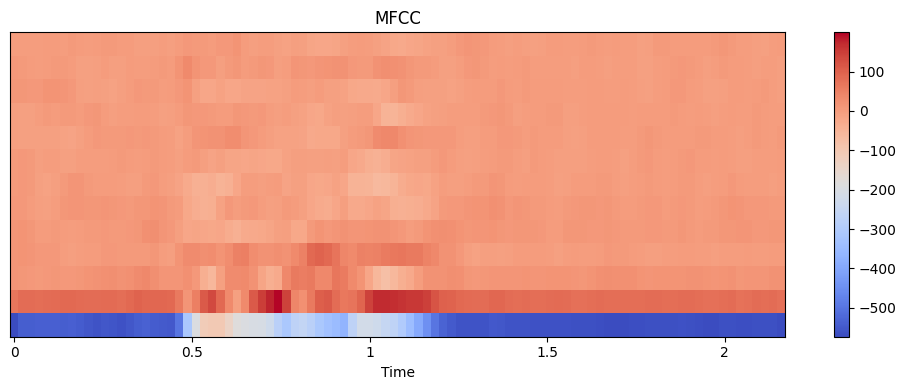

In [42]:
enroll_user("user5")
enroll_user("user6")
enroll_user("user7")
enroll_user("user8")

🎙️ Recording for user: user9


<IPython.core.display.Javascript object>

✅ Enrolled user9 — Saved at /content/drive/MyDrive/voice_enrollments/user9.wav


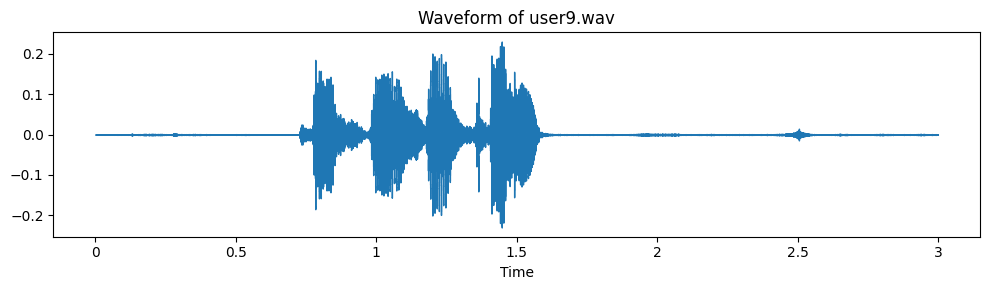

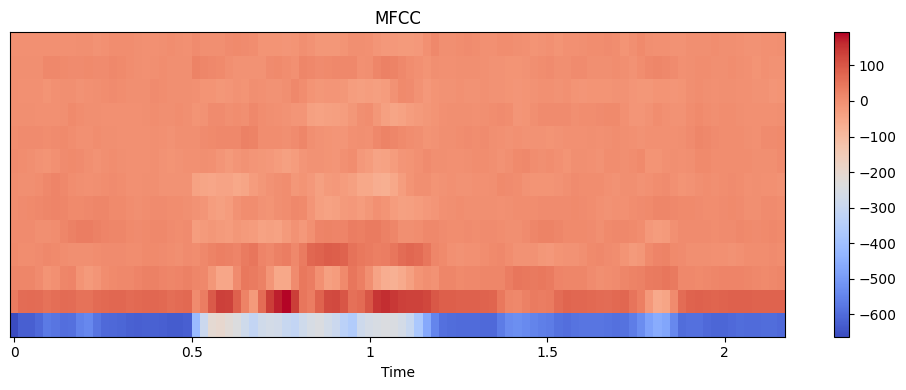

🎙️ Recording for user: user10


<IPython.core.display.Javascript object>

✅ Enrolled user10 — Saved at /content/drive/MyDrive/voice_enrollments/user10.wav


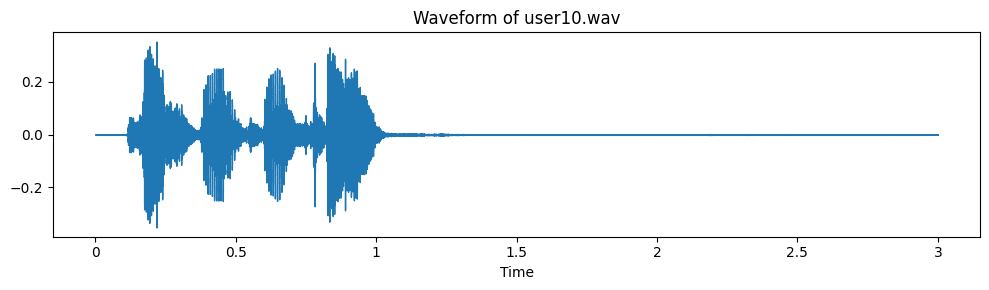

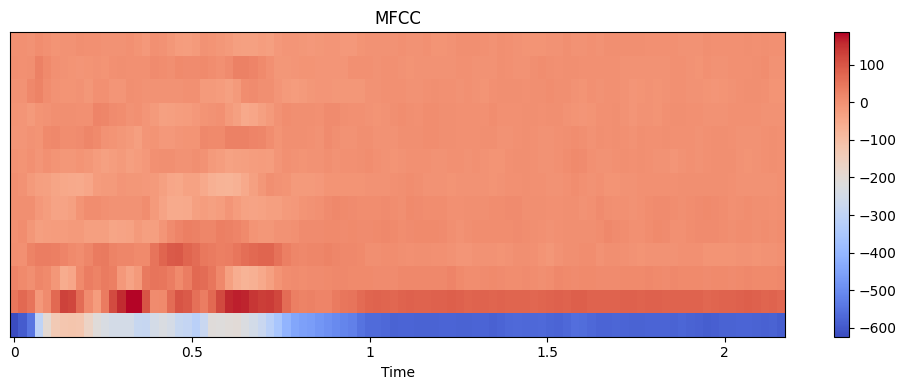

🎙️ Recording for user: user11


<IPython.core.display.Javascript object>

✅ Enrolled user11 — Saved at /content/drive/MyDrive/voice_enrollments/user11.wav


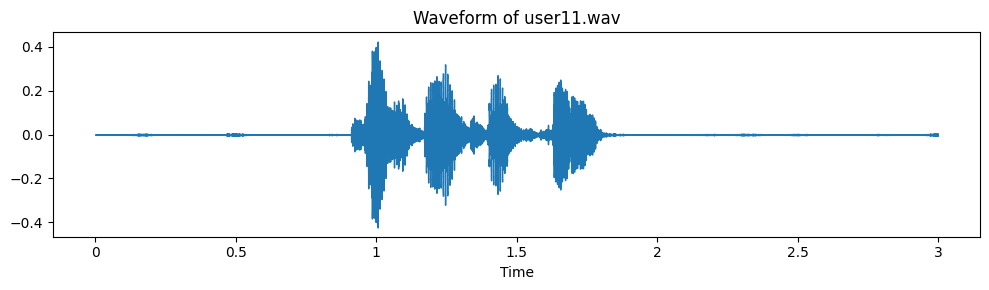

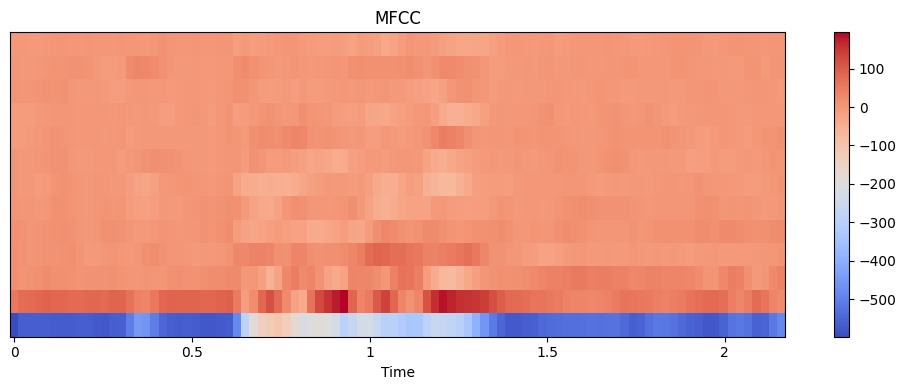

🎙️ Recording for user: user12


<IPython.core.display.Javascript object>

✅ Enrolled user12 — Saved at /content/drive/MyDrive/voice_enrollments/user12.wav


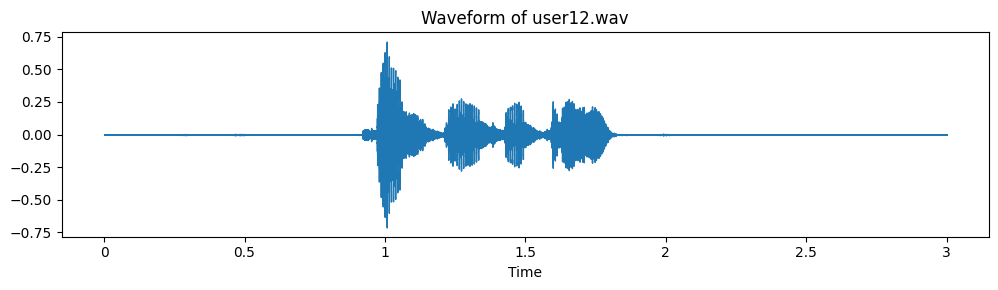

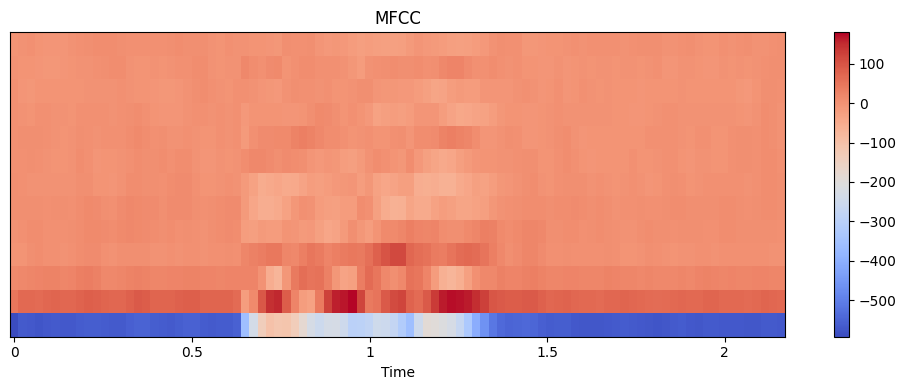

In [43]:
enroll_user("user9")
enroll_user("user10")
enroll_user("user11")
enroll_user("user12")

🎙️ Recording for user: user13


<IPython.core.display.Javascript object>

✅ Enrolled user13 — Saved at /content/drive/MyDrive/voice_enrollments/user13.wav


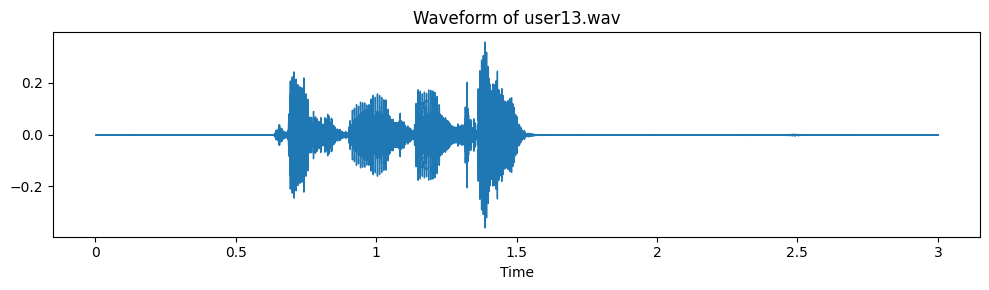

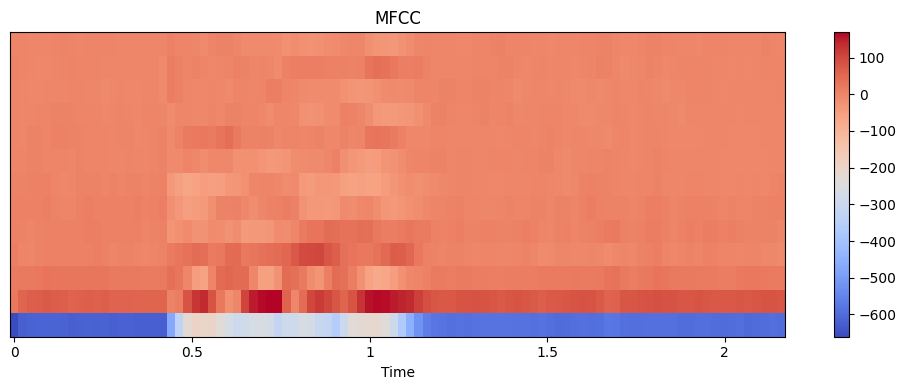

🎙️ Recording for user: user14


<IPython.core.display.Javascript object>

✅ Enrolled user14 — Saved at /content/drive/MyDrive/voice_enrollments/user14.wav


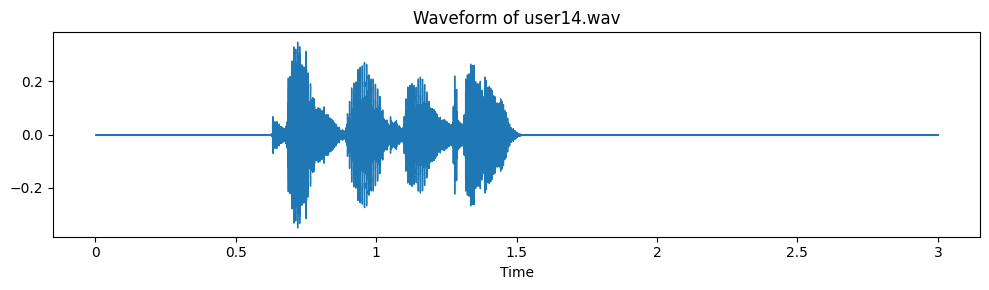

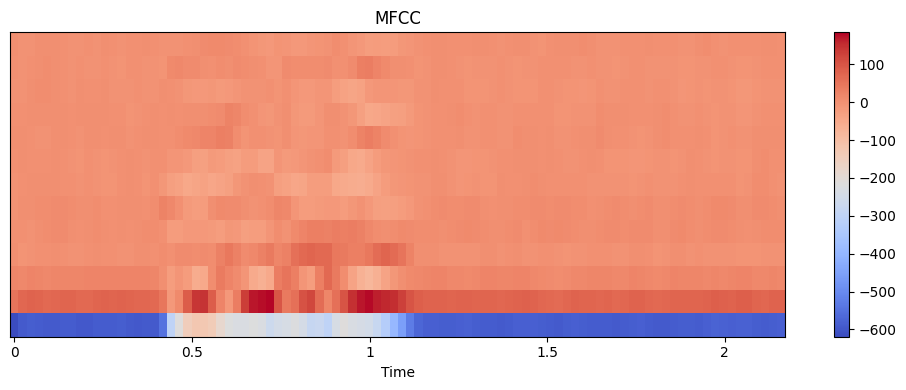

🎙️ Recording for user: user15


<IPython.core.display.Javascript object>

✅ Enrolled user15 — Saved at /content/drive/MyDrive/voice_enrollments/user15.wav


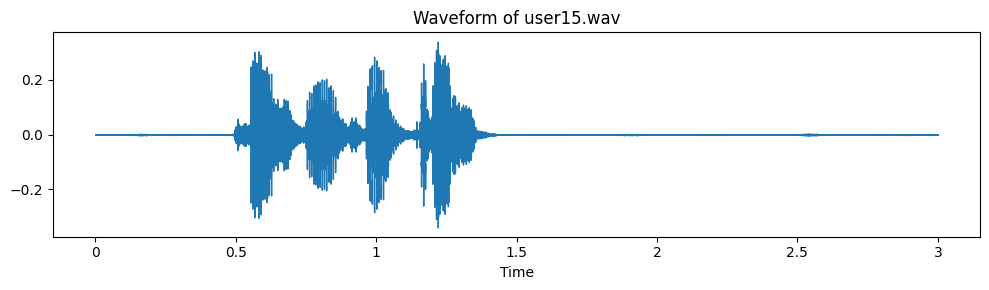

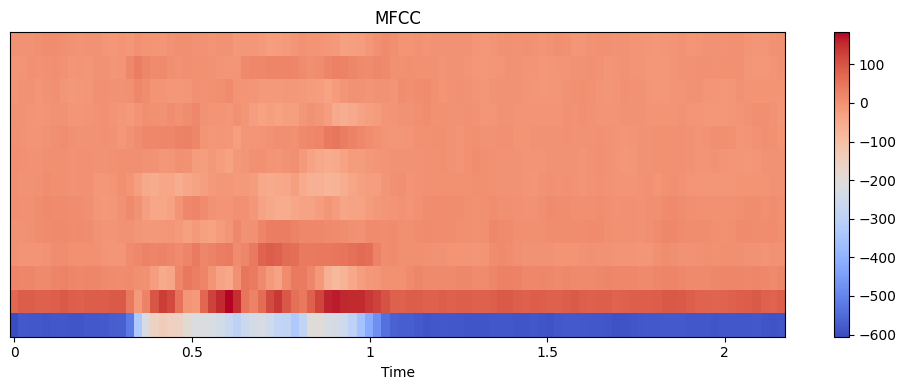

🎙️ Recording for user: user16


<IPython.core.display.Javascript object>

✅ Enrolled user16 — Saved at /content/drive/MyDrive/voice_enrollments/user16.wav


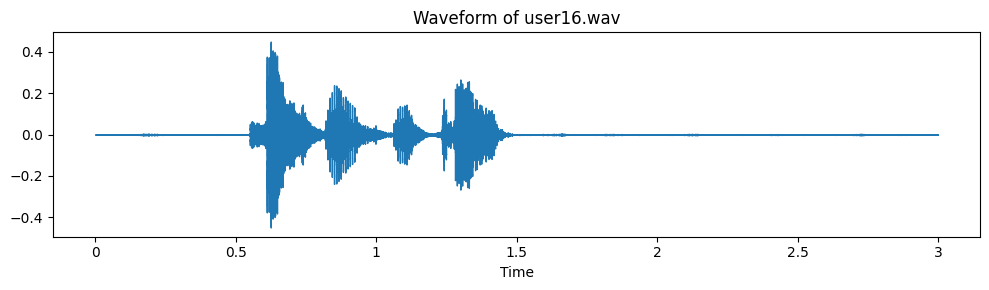

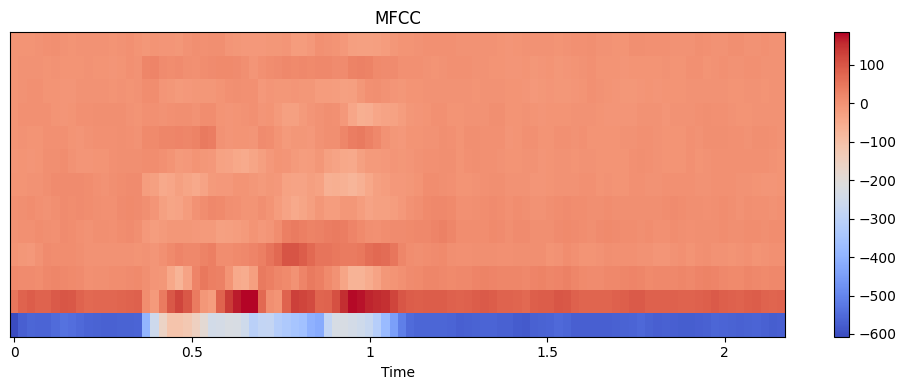

In [44]:
enroll_user("user13")
enroll_user("user14")
enroll_user("user15")
enroll_user("user16")

🎙️ Recording for user: user17


<IPython.core.display.Javascript object>

✅ Enrolled user17 — Saved at /content/drive/MyDrive/voice_enrollments/user17.wav


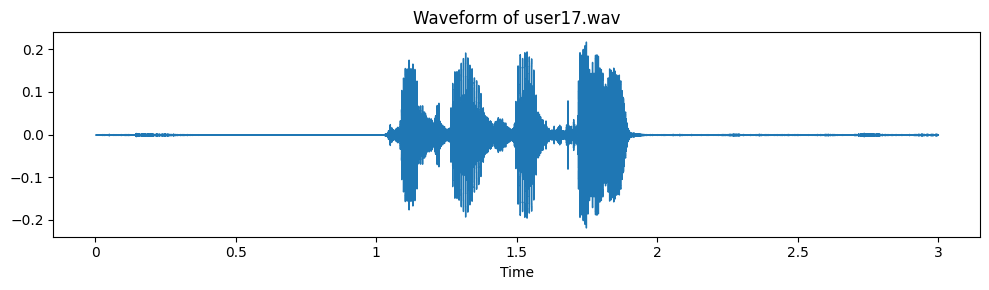

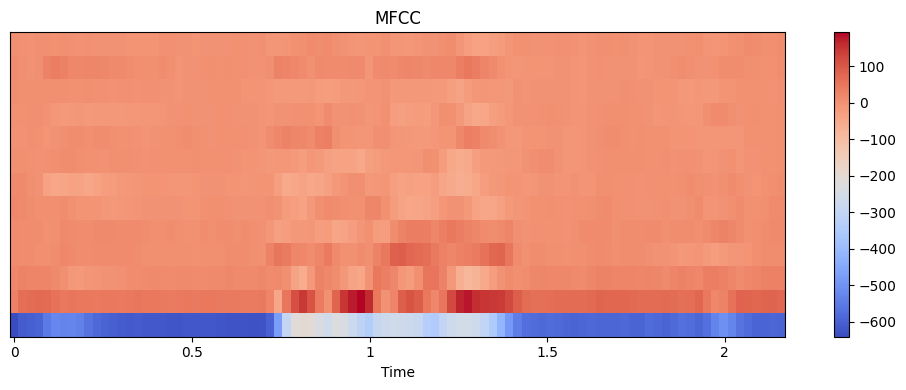

🎙️ Recording for user: user18


<IPython.core.display.Javascript object>

✅ Enrolled user18 — Saved at /content/drive/MyDrive/voice_enrollments/user18.wav


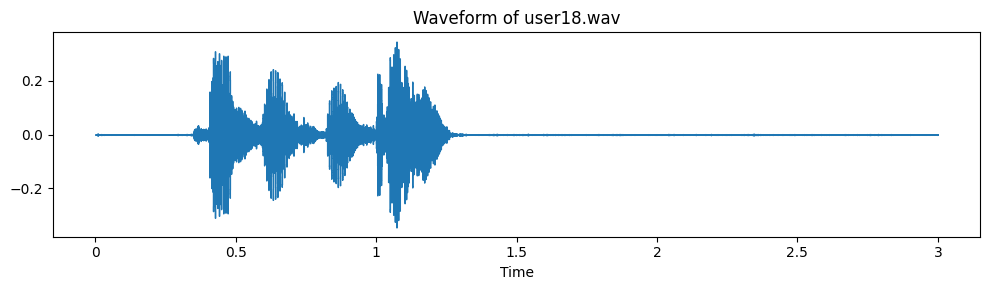

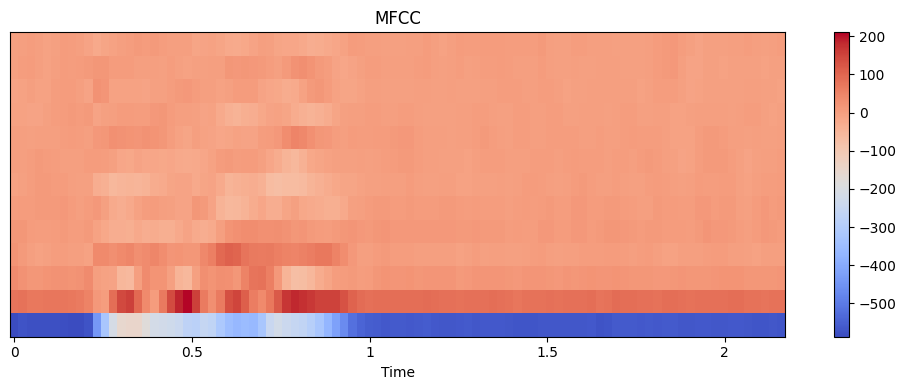

🎙️ Recording for user: user19


<IPython.core.display.Javascript object>

✅ Enrolled user19 — Saved at /content/drive/MyDrive/voice_enrollments/user19.wav


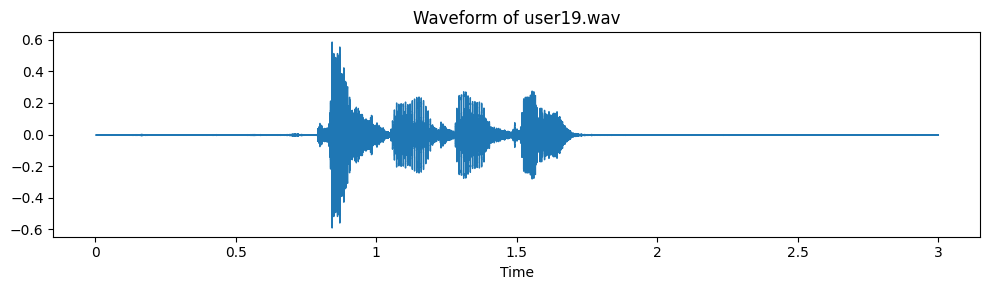

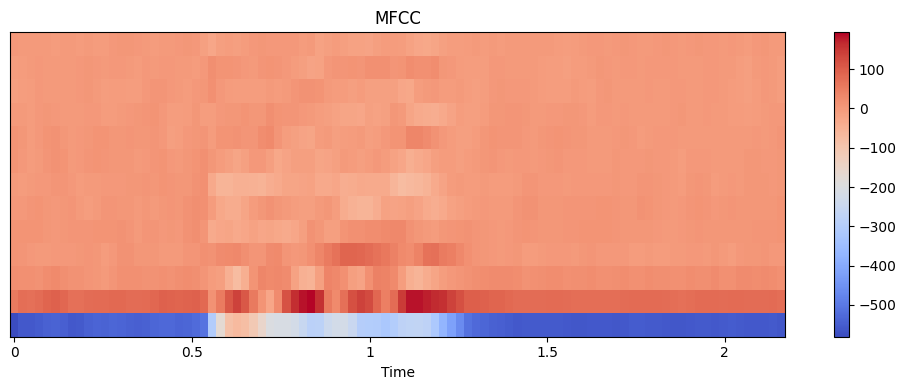

🎙️ Recording for user: user20


<IPython.core.display.Javascript object>

✅ Enrolled user20 — Saved at /content/drive/MyDrive/voice_enrollments/user20.wav


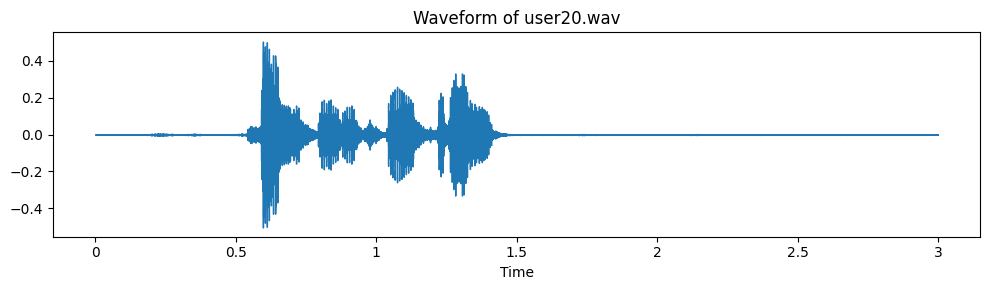

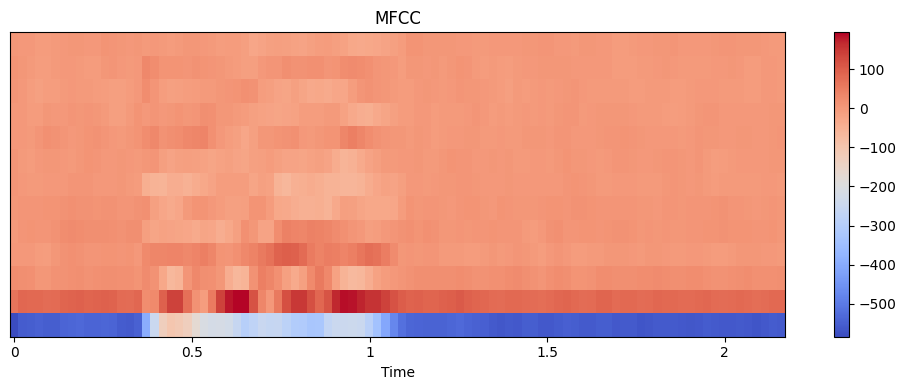

In [45]:
enroll_user("user17")
enroll_user("user18")
enroll_user("user19")
enroll_user("user20")


📥 Recording your test voice...


<IPython.core.display.Javascript object>

✅ Recorded test sample: test.wav


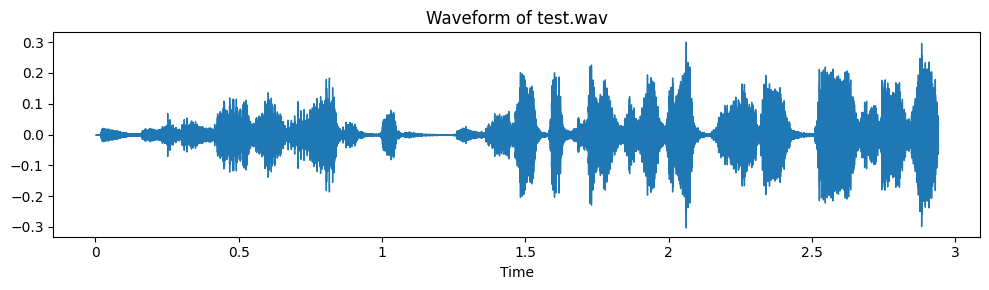

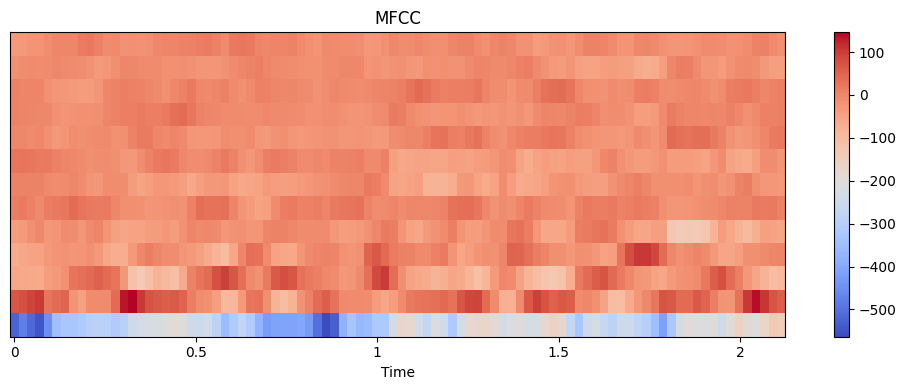


🔎 MFCC Similarity Comparison:
📂 user1: 97.7% similarity — ❌ Fail
📂 user2: 97.4% similarity — ❌ Fail
📂 user3: 97.5% similarity — ❌ Fail
📂 user4: 97.6% similarity — ❌ Fail
📂 user5: 97.7% similarity — ❌ Fail
📂 user6: 97.5% similarity — ❌ Fail
📂 user7: 97.4% similarity — ❌ Fail
📂 user8: 97.3% similarity — ❌ Fail
📂 user9: 97.9% similarity — ❌ Fail
📂 user10: 97.7% similarity — ❌ Fail
📂 user11: 97.7% similarity — ❌ Fail
📂 user12: 97.4% similarity — ❌ Fail
📂 user13: 97.8% similarity — ❌ Fail
📂 user14: 97.8% similarity — ❌ Fail
📂 user15: 97.6% similarity — ❌ Fail
📂 user16: 97.4% similarity — ❌ Fail
📂 user17: 97.9% similarity — ❌ Fail
📂 user18: 97.4% similarity — ❌ Fail
📂 user19: 97.5% similarity — ❌ Fail
📂 user20: 97.3% similarity — ❌ Fail

🏆 Top 5 Matches:
  user9: 97.9%
  user17: 97.9%
  user14: 97.8%
  user13: 97.8%
  user10: 97.7%

❌ Access Denied — No match found


In [81]:
voice_authentication_mfcc(threshold=99.9, top_n=5)